# Binned Shear Likelihood Example

In [1]:
from pathlib import Path
import sys

project_root = next(
    (
        candidate
        for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (candidate / "src" / "likelihood" / "binned_shear.py").exists()
    ),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(project_root))

from src.likelihood.wtg import WtGLikelihood
from src.utils.utils import CoordSystem

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from chainconsumer import Chain, ChainConsumer, PlotConfig
from astropy.table import Table
from numcosmo_py import Nc, Ncm

__name__ = "NcContext"

Ncm.cfg_init()
Ncm.cfg_set_log_handler(lambda msg: None)

In [2]:
custom_params = {
    "figure.dpi": 500,
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
}

sns.set_theme(
    context="paper",
    style="ticks",
    palette="colorblind",
    rc=custom_params,
)

## Create NumCosmo model set

In [3]:
ra = 37.865017
dec = 6.982205
z = 0.22
r_max = 2.62
r_min = 0.5
c = 2.3
log10m = 14.9

In [4]:
# Generate cosmology
cosmo = Nc.HICosmoDEXcdm()
prim = Nc.HIPrimPowerLaw.new()
tf = Nc.TransferFuncEH()
psml = Nc.PowspecMLTransfer.new(tf)
reion = Nc.HIReionCamb.new()

cosmo.params_set_default_ftype()
cosmo.omega_x2omega_k()
psml.require_kmin(1.0e-6)
psml.require_kmax(1.0e3)
cosmo.add_submodel(prim)
cosmo.add_submodel(reion)

cosmo["H0"] = 70
cosmo["Omegab"] = 0.045
cosmo["Omegac"] = 0.3 - 0.045
cosmo["w"] = -1.0
cosmo["Omegak"] = 0.00
prim["ln10e10ASA"] = 3.02745

# Set A_s to match shear8=0.8120 for the PlaNck 2018 cosmology
A_s_fid = np.exp(prim["ln10e10ASA"]) * 1.0e-10
shear8 = 0.8120
shear8_fid_norm = psml.sigma_tophat_R(cosmo, 1.0e-7, 0.0, 8.0 / cosmo.h())
fact = (shear8 / shear8_fid_norm) ** 2

prim["n_SA"] = 0.9649
prim["ln10e10ASA"] = np.log(1.0e10 * A_s_fid * fact)

cosmo.param_set_desc("H0", {"fit": False})
cosmo.param_set_desc("Omegac", {"fit": False})
cosmo.param_set_desc("Omegab", {"fit": False})
cosmo.param_set_desc("w", {"fit": False})
cosmo.param_set_desc("Omegak", {"fit": False})
prim.param_set_desc("ln10e10ASA", {"fit": False})
prim.param_set_desc("n_SA", {"fit": False})
reion.param_set_desc("z_re", {"fit": False})


dist = Nc.Distance.new(6.0)
hms = Nc.HaloCMParam.new(Nc.HaloMassSummaryMassDef.CRITICAL, 500.0)
dp = Nc.HaloDensityProfileNFW.new(hms)
smd = Nc.WLSurfaceMassDensity.new(dist)
hp = Nc.HaloPosition.new(dist)

hp["ra"] = ra
hp["dec"] = dec
hp["z"] = z
hms["log10MDelta"] = log10m
hms["cDelta"] = c

smd.prepare(cosmo)
hp.prepare(cosmo)

mset = Ncm.MSet.new_array(
    [
        cosmo,
        dp,
        smd,
        hp,
    ]
)

## Load data

In [5]:
abell360_table = Table.read(
    "../../abell360/data/shapeHSM_calibrated_colorcuts-pzcuts.fits"
)
object_calibration = Table.read("../../abell360/data/object_calibration.fits")
abell360_pz = np.load("../../abell360/data/shapeHSM_dnf_pzs.npy")
bins = np.linspace(0.0, 3.0, 301)

abell360_df = abell360_table.to_pandas()
abell360_df["pz_weights"] = abell360_pz.tolist()
abell360_df["pz_nodes"] = [bins] * len(abell360_df)
abell360_df = abell360_df.merge(
    object_calibration.to_pandas(),
    how="left",
    left_index=True,
    right_index=True,
)
abell360_df = abell360_df[
    [
        "coord_ra",
        "coord_dec",
        "i_hsmShapeRegauss_e1",
        "i_hsmShapeRegauss_e2",
        "i_hsmShapeRegauss_sigma",
        "i_hsmshaperegauss_derived_sigma_e",
        "i_hsmshaperegauss_derived_rms_e",
        "i_hsmshaperegauss_derived_shear_bias_m",
        "i_hsmshaperegauss_derived_shear_bias_c1",
        "i_hsmshaperegauss_derived_shear_bias_c2",
        "dnf_z_mean",
        "dnf_z_mode",
        "dnf_z_median",
        "pz_weights",
        "pz_nodes",
    ]
]
abell360_df = abell360_df.rename(
    columns={
        "coord_ra": "i_ra",
        "coord_dec": "i_dec",
        "i_hsmShapeRegauss_e1": "i_hsmshaperegauss_e1",
        "i_hsmShapeRegauss_e2": "i_hsmshaperegauss_e2",
        "dnf_z_mode": "z",
    }
)

## Create Likelihood

In [6]:
likelihood = WtGLikelihood(
    mset=mset,
    fparams_bounds=[(13.5, 15.5)],
    obs=abell360_df,
    coord_system=CoordSystem.EUCLIDEAN,
    radius_bounds=(r_min / cosmo.h(), r_max / cosmo.h()),
)

In [ ]:
likelihood.prepare_data()
mle = likelihood.maximum_likelihood_estimate()

print(f"\nMLE log10MDelta = {mle[0]:.3f}\n")

posterior = likelihood.sample_posterior(
    nsamples=2000,
    nwalkers=32,
    nthreads=16,
    progress=True,
)
posterior.rename(columns={"log10MDelta": r"$\log_{10}M_{500c}$"}, inplace=True)


MLE log10MDelta = 14.856



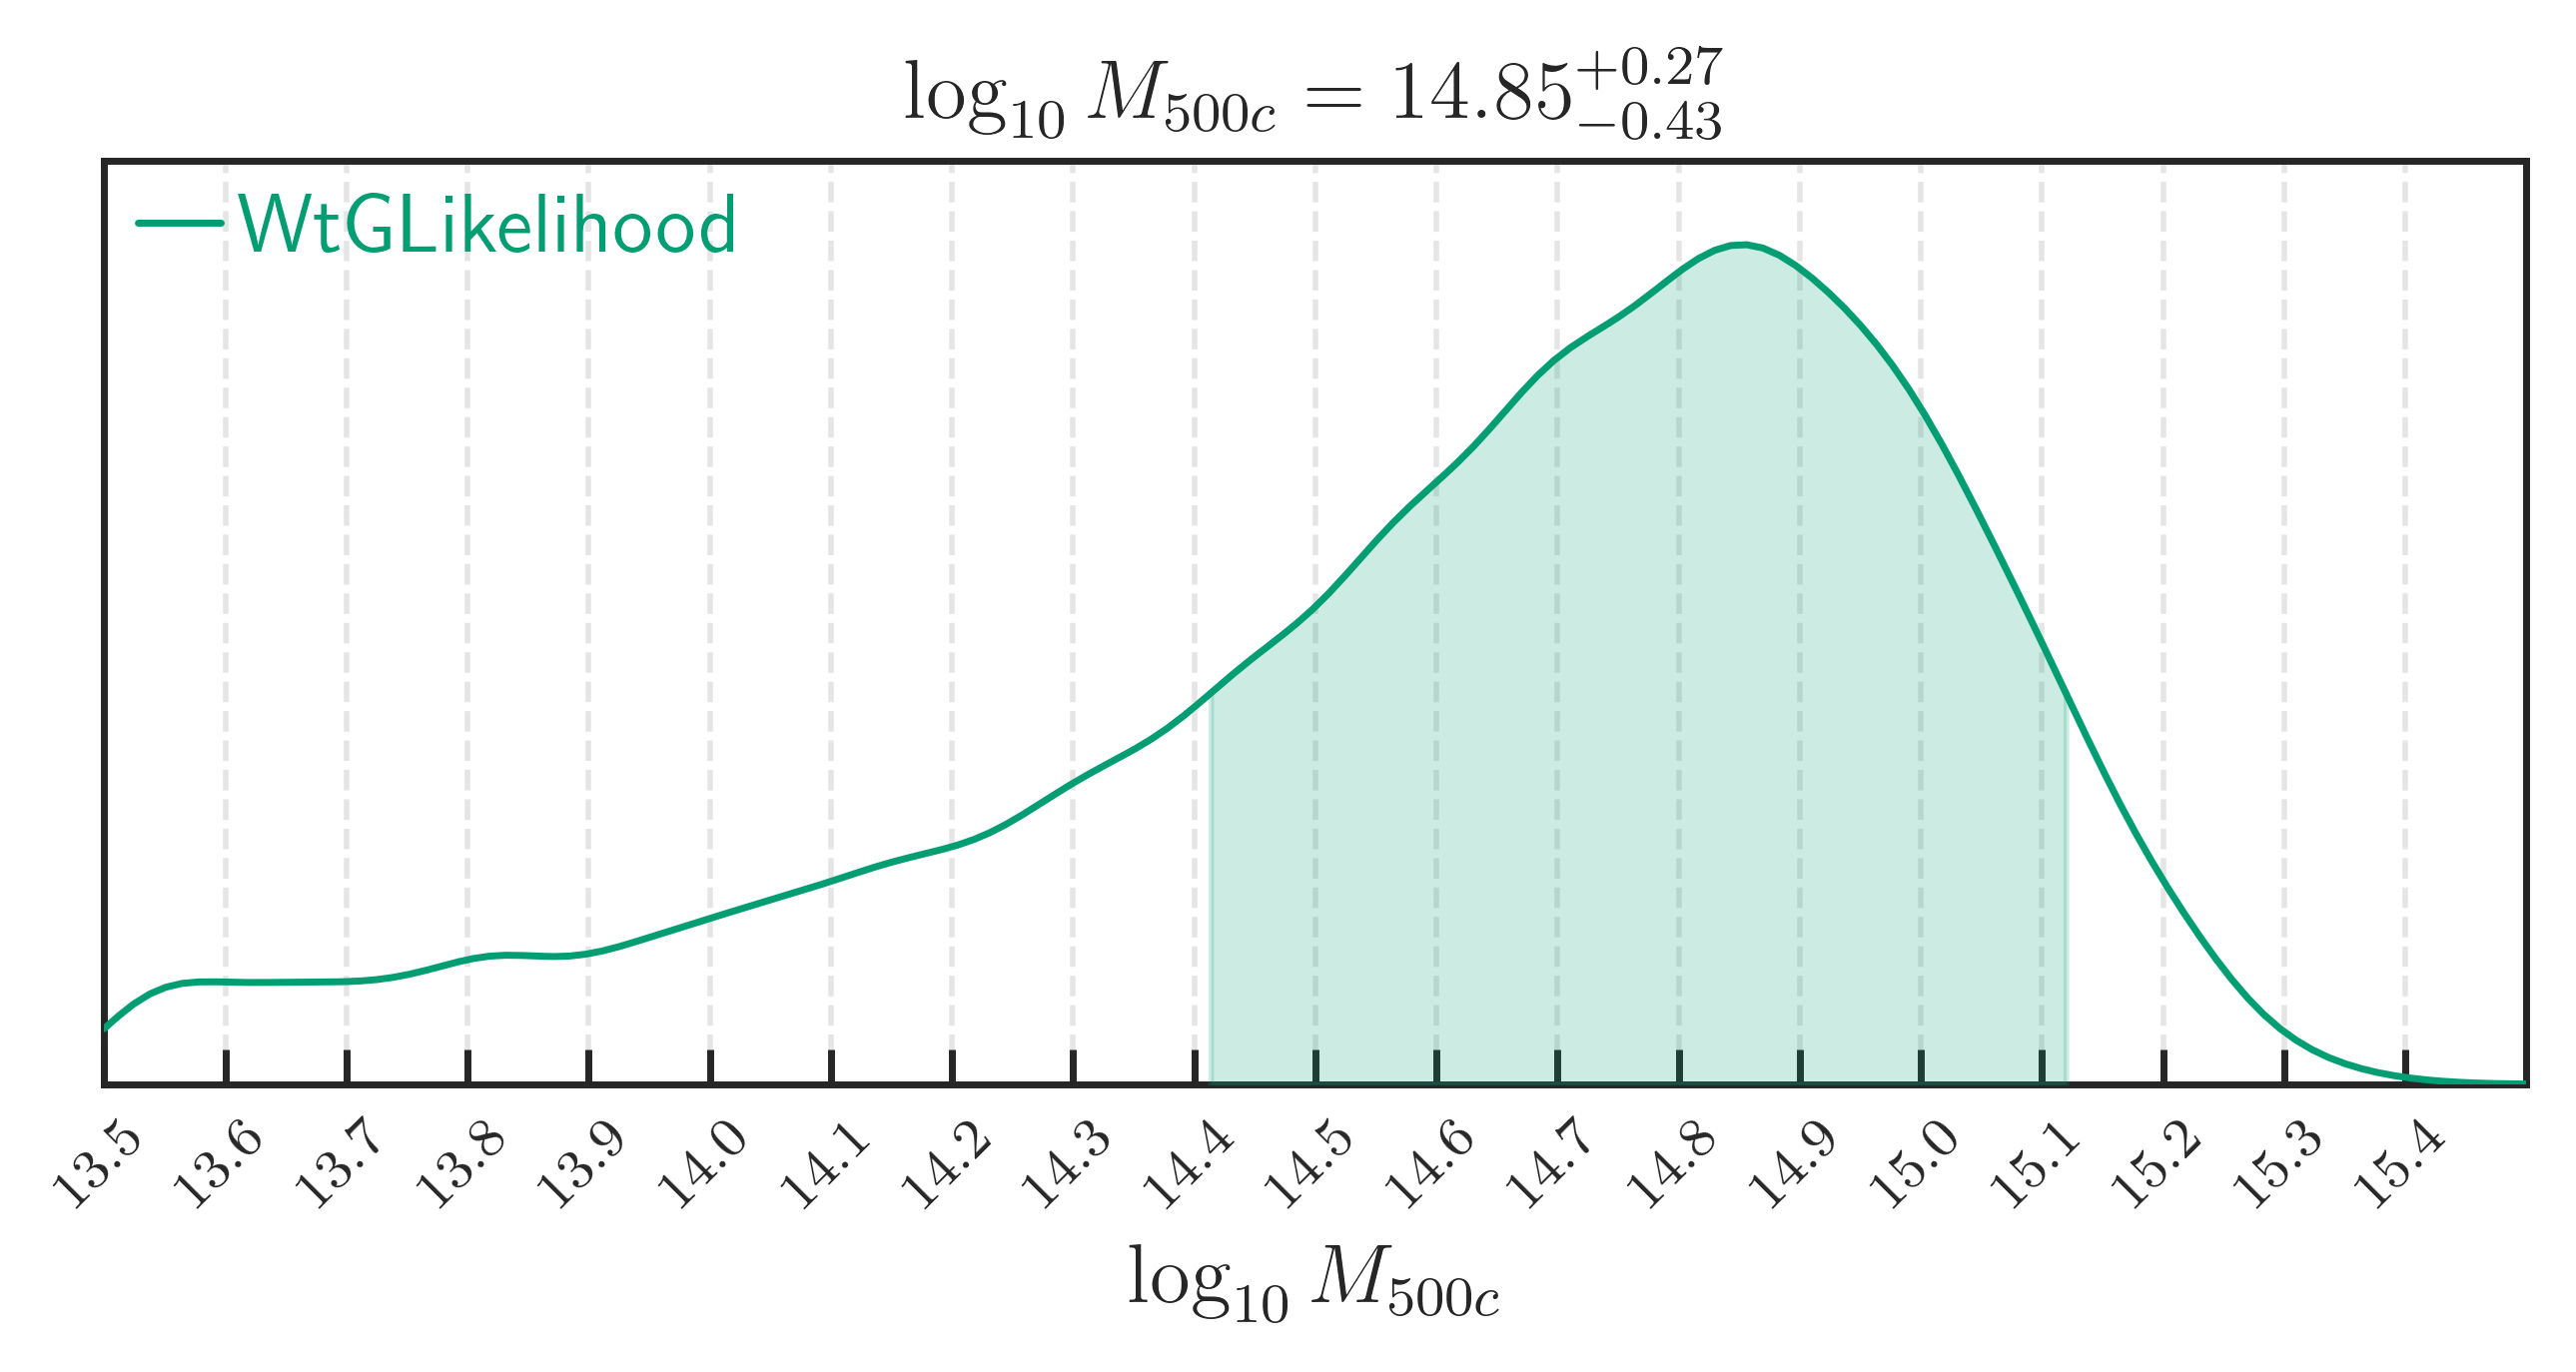

In [ ]:
cc = ChainConsumer()
binned_shear_chain = Chain(
    samples=posterior,
    name="WtGLikelihood",
    color=sns.color_palette("colorblind")[2],
)
plot_config = PlotConfig(
    summarise=True,
    show_legend=True,
    legend_color_text=True,
    usetex=True ,
    tick_font_size=8,
    diagonal_tick_labels=True,
)

cc.add_chain(binned_shear_chain)
cc.set_plot_config(plot_config)

fig = cc.plotter.plot(figsize=(6, 3))

legend = fig.axes[0].get_legend()
if legend is not None:
    legend.set_loc("upper left")

fig.axes[0].set_xticks(np.arange(13.5, 15.5, 0.1))
fig.axes[0].set_xlim(13.5, 15.5)
fig.axes[0].grid(True, which="both", ls="--", alpha=0.5)

plt.show()